# Logo Moodle

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.color as clr
import scipy.ndimage as ndi

In [12]:
def display(img):
    img = (img-img.min()) / (img.max()-img.min())
    plt.figure(figsize=(6,6))
    plt.imshow(img, vmax=255)
    plt.xticks([])
    plt.yticks([])
    plt.show()

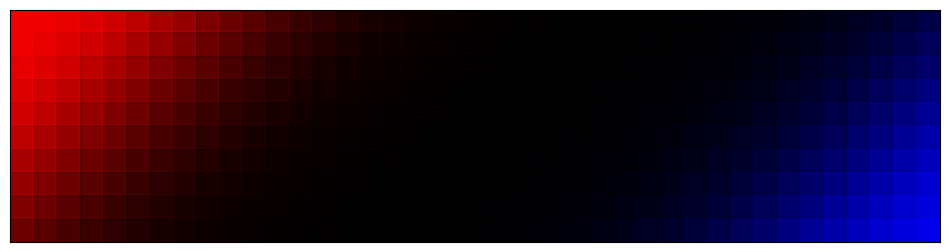

In [35]:
def red(r,c):
    # return 0
    # return np.cos(c/C*np.pi/2)*255
    # return 255 * np.exp(-(c)**2/200**2)
    return 255 * np.exp(-(c+r)**2/200**2)

def green(r,c):
    return 0
    # return np.cos(c/C*np.pi/2 - np.pi/4)*255
    # return 255 * np.exp(-(c-C/2)**2/200**2)

def blue(r,c):
    # return 0
    # return np.cos(c/C*np.pi/2 - np.pi/2)*255
    # return 255 * np.exp(-(c-C)**2/200**2)
    return 255 * np.exp(-(c-C+r-R)**2/200**2)


# Taille de l'image
R, C = 200, 800

# Taille des carrés
S = 20

logo = np.ones((R,C,3))

for r in range(0,R,S):
    for c in range(0,C,S):
        logo[r:r+S, c:c+S, :] = [red(r,c), green(r,c), blue(r,c)]

# # Grille
# for c in range(S,C,S):
#     logo[:, c, :] = np.ones((R,3)) * 255
# for r in range(S,R,S):
#     logo[r, :, :] = np.ones((C,3)) * 255

# Réhaussement de contour (à la placer de la grille) ?
h = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0],
])
for b in range(3):
    logo[:,:,b] = ndi.convolve(logo[:,:,b]*1., h)

display(logo)

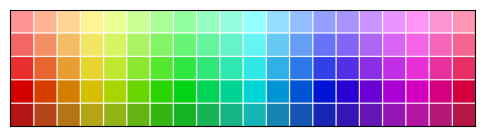

In [47]:
def hue(r,c):
    # return 0
    # return c/C
    # return 255 * np.exp(-(c)**2/200**2)
    
    a = c - C/2 + 1e-9
    b = r - R/2
    if  a>=0:
        theta = np.atan(b/a)
    else:
        theta = np.atan(-b/a+np.pi)
    # return theta / (2*np.pi)

    return c/C
    
    #return np.atan( (r-R/2) / (c-C/2+1e-9) ) / (np.pi)

def saturation(r,c):
    # return 1
    return np.exp( 2*r/R )
    # return (R-r)/R*.7 + (1-.7)
    # return np.cos(c/C*np.pi/2 - np.pi/4)*255
    # return 255 * np.exp(-(c-C/2)**2/200**2)

def value(r,c):
    # return 1
    return np.log( 10*(R-r)/R )
    # return (R-r)/R
    # return np.cos(c/C*np.pi/2 - np.pi/2)*255
    # return 255 * np.exp(-(c-C)**2/200**2)


# Taille de l'image
R, C = 200, 800

# Taille des carrés
S = 40

logo = np.ones((R,C,3))

for r in range(0,R,S):
    for c in range(0,C,S):
        logo[r:r+S, c:c+S, :] = [hue(r,c), saturation(r,c), value(r,c)]

logo = clr.hsv2rgb(logo)
                     
# # Réhaussement de contour (à la placer de la grille) ?
# h = np.array([
#     [0, -1, 0],
#     [-1, 5, -1],
#     [0, -1, 0],
# ])
# for b in range(3):
#     logo[:,:,b] = ndi.convolve(logo[:,:,b]*1., h)

# Grille
ma = np.max(np.ravel(logo))
for c in range(S,C,S):
    logo[:, c, :] = np.ones((R,3)) * ma
    logo[:, c+1, :] = np.ones((R,3)) * ma
for r in range(S,R,S):
    logo[r, :, :] = np.ones((C,3)) * ma
    logo[r+1, :, :] = np.ones((C,3)) * ma

display(logo)

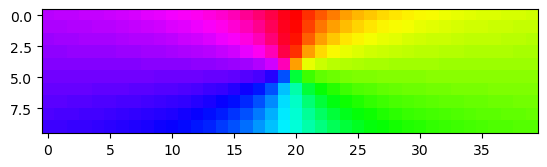

In [25]:

    # return theta/(2*np.pi)
    # #return np.atan( (r-R/2) / (c-C/2+1e-9) ) / (np.pi)

R, C = 10, 40
rr = np.linspace(-R/2, R/2, R)
cc = np.linspace(-C/2, C/2, C)
logo = np.ones((R,C))

for r in range(R):
    for c in range(C):
        a = cc[c] + 1e-9
        b = rr[r] + 1e-9
        if  a>=0:
            theta = np.atan(b/a)
        else:
            theta = np.atan(b/a) + np.pi
        logo[r, c] = theta

plt.imshow(logo, 'hsv')